In [2]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [4]:
torch.manual_seed(42)
X = torch.rand(100, 1) * 10
y = 2 * X + 3 + torch.randn(100, 1)

In [7]:
class CustomActivationModel(nn.Module):
  def __init__(self):
    super(CustomActivationModel, self).__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self,x):
    linear_x = self.linear(x)
    activated_x = torch.tanh(linear_x)
    return linear_x + activated_x

model = CustomActivationModel()
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [8]:
epochs = 1000
for epoch in range(epochs):
    model.train()
    predictions = model(X)
    loss = criterion(predictions, y)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 1.1104
Epoch [200/1000], Loss: 0.8213
Epoch [300/1000], Loss: 0.7216
Epoch [400/1000], Loss: 0.6851
Epoch [500/1000], Loss: 0.6714
Epoch [600/1000], Loss: 0.6662
Epoch [700/1000], Loss: 0.6643
Epoch [800/1000], Loss: 0.6635
Epoch [900/1000], Loss: 0.6633
Epoch [1000/1000], Loss: 0.6632


In [9]:
from matplotlib import pyplot as plt

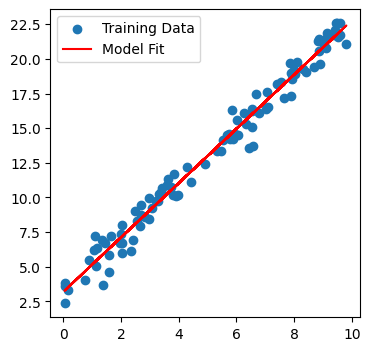

Predictions for [[4.0], [7.0]]: [[11.04050064086914], [16.90799903869629]]


In [11]:
plt.figure(figsize=(4, 4))
plt.scatter(X, y, label='Training Data')
plt.plot(X, predictions.detach().numpy(), 'r', label='Model Fit')
plt.legend()
plt.show()

X_test = torch.tensor([[4.0], [7.0]])
with torch.no_grad():
    predictions = model(X_test)
    print(f"Predictions for {X_test.tolist()}: {predictions.tolist()}")